# End-to-End Autonomous Driving: VLA + World Models

This notebook demonstrates three SOTA paradigms for autonomous driving:

| # | Paradigm | Key Idea | Model |
|---|---|---|---|
| 1 | **End-to-End Planning** | Unified perception→prediction→planning | UniAD |
| 2 | **Vision-Language-Action** | LLM/VLM reasoning for driving | DriveVLM |
| 3 | **World Models** | Predict future, plan in imagination | Vista/GenAD |

```
Multi-Camera Input → BEV Features → {Detection, Motion, Planning}
                                   → {CoT Reasoning → Trajectory}
                                   → {Latent Dynamics → MPC Planning}
```

In [1]:
import sys
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
import yaml

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## 1. Load nuScenes Data

We use the nuScenes mini dataset (10 scenes, ~4GB) which includes:
- 6 surround cameras (360° coverage)
- 32-beam LiDAR
- Full 3D annotations (23 classes)
- HD maps

In [2]:
from src.data.nuscenes_loader import NuScenesLoader

dataset = NuScenesLoader(
    dataroot='../data/nuscenes',
    version='v1.0-mini',
    split='mini_train',
    image_size=(224, 400),
)

print(f'Dataset size: {len(dataset)} samples')

# Load a sample
sample = dataset[0]
batch = dataset.collate_fn([sample])

# Move to device
for k, v in batch.items():
    if isinstance(v, torch.Tensor):
        batch[k] = v.to(device)

print(f'Images shape: {batch["images"].shape}')  # (1, 6, 3, 224, 400)
print(f'Intrinsics shape: {batch["intrinsics"].shape}')
print(f'Future trajectory: {batch["future_trajectory"].shape}')

Loading nuScenes v1.0-mini from ../data/nuscenes...
Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.157 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
Loaded 323 samples from 8 scenes
Dataset size: 323 samples
Images shape: torch.Size([1, 6, 3, 224, 400])
Intrinsics shape: torch.Size([1, 6, 3, 3])
Future trajectory: torch.Size([1, 6, 2])


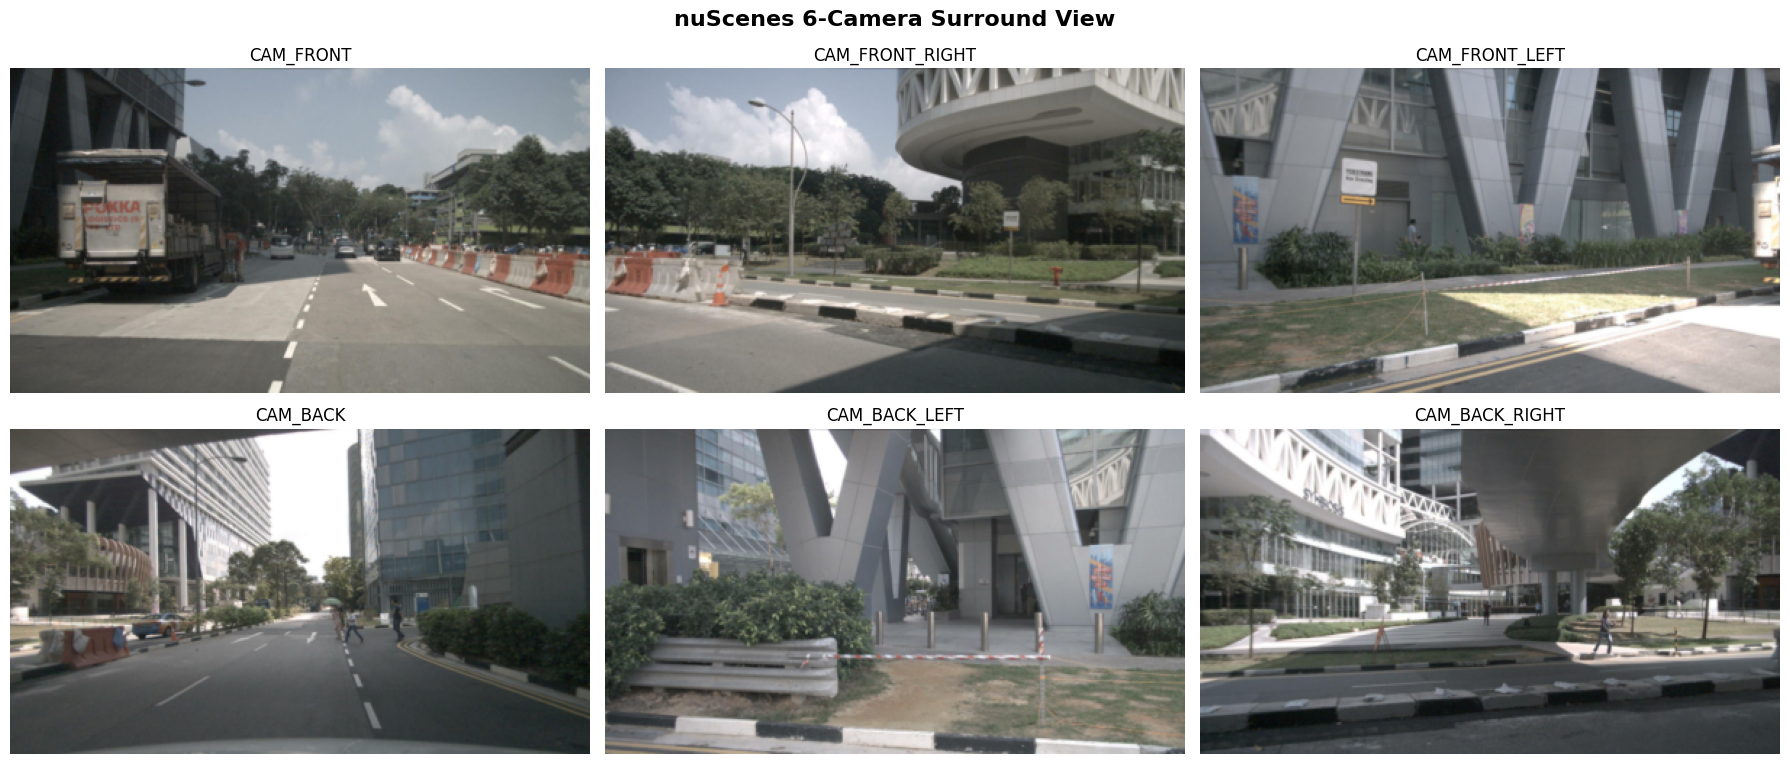

In [3]:
# Visualize the 6 camera views
from src.data.nuscenes_loader import CAMERA_NAMES, IMG_MEAN, IMG_STD

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for i, (ax, cam) in enumerate(zip(axes.flat, CAMERA_NAMES)):
    img = batch['images'][0, i].cpu().numpy().transpose(1, 2, 0)  # CHW → HWC
    img = img * IMG_STD + IMG_MEAN  # Denormalize
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(cam, fontsize=12)
    ax.axis('off')

plt.suptitle('nuScenes 6-Camera Surround View', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## 2. BEV Feature Extraction (Lift-Splat-Shoot)

The core shared component across all three paradigms: transform multi-camera images to a Bird's Eye View (BEV) representation.

```
6 Cameras × (3, 224, 400)
    ↓ ResNet-50 backbone
6 × (256, 14, 25) image features
    ↓ Depth prediction per pixel
6 × (64, 14, 25) depth distributions
    ↓ Lift: outer product → 3D point cloud
    ↓ Splat: voxel pooling onto BEV grid
(256, 200, 200) BEV features
```

In [4]:
from src.e2e_planner.model import ImageBackbone
from src.data.bev_transform import BEVTransform

# Build backbone + BEV transform
backbone = ImageBackbone('resnet50', pretrained=True, out_channels=256).to(device)
bev_transform = BEVTransform(
    in_channels=256, bev_channels=256,
    bev_size=(200, 200),
    bev_range=(-50.0, -50.0, 50.0, 50.0),
).to(device)

# Extract features
with torch.no_grad():
    img_features = backbone(batch['images'])
    bev = bev_transform(img_features, batch['intrinsics'], batch['extrinsics'])

print(f'Image features: {img_features.shape}')
print(f'BEV features: {bev.shape}')

# Visualize BEV
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
bev_np = bev[0].cpu().numpy()

axes[0].imshow(bev_np.mean(0), cmap='viridis', origin='lower')
axes[0].set_title('BEV Mean Activation')

axes[1].imshow(bev_np.max(0), cmap='hot', origin='lower')
axes[1].set_title('BEV Max Activation')

axes[2].imshow(bev_np.std(0), cmap='plasma', origin='lower')
axes[2].set_title('BEV Std (uncertainty)')

for ax in axes:
    ax.axis('off')

plt.suptitle('BEV Feature Maps (200×200, 100m×100m)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

RuntimeError: Input type (torch.cuda.DoubleTensor) and weight type (torch.cuda.FloatTensor) should be the same

## 3. Paradigm 1: End-to-End Planner (UniAD)

**Key idea:** Cascade of task-specific transformer decoders, all optimized for the final planning objective.

```
BEV → DETR Detection (300 queries)
    → Motion Forecasting (6 modes × 6 steps)
    → Ego Planning (collision-aware GRU)
```

**Why SOTA:** CVPR 2023 Best Paper. Showed that joint multi-task learning with planning as the ultimate objective outperforms modular pipelines.

In [5]:
from src.e2e_planner.model import UniADPlanner

with open('../configs/e2e_planner.yaml') as f:
    e2e_config = yaml.safe_load(f)

planner = UniADPlanner(e2e_config).to(device)
print(f'UniAD parameters: {sum(p.numel() for p in planner.parameters())/1e6:.1f}M')

# Run inference
with torch.no_grad():
    e2e_outputs = planner.predict(batch)

# Print results
traj = e2e_outputs['planned_trajectory'][0].cpu().numpy()
print(f'\nPlanned trajectory ({len(traj)} waypoints):')
for t, (x, y) in enumerate(traj):
    print(f'  t+{t+1}: x={x:+.2f}m, y={y:+.2f}m')

print(f'\nCollision scores: {e2e_outputs["collision_scores"][0].cpu().numpy()}')
print(f'Detections (conf > 0.3): {(e2e_outputs["detection_scores"][0] > 0.3).sum().item()}')

UniAD parameters: 17.0M


RuntimeError: Input type (torch.cuda.DoubleTensor) and weight type (torch.cuda.FloatTensor) should be the same

In [6]:
# Visualize E2E planner outputs
from src.visualization.bev_visualizer import BEVVisualizer

vis = BEVVisualizer()
fig = vis.visualize_e2e(e2e_outputs, title='UniAD — End-to-End Planner')
plt.show()

NameError: name 'e2e_outputs' is not defined

## 4. Paradigm 2: VLA Agent (DriveVLM)

**Key idea:** Use a Vision-Language Model to reason about the scene via Chain-of-Thought, then convert reasoning to a trajectory.

```
BEV → Visual Projector → [visual tokens]
  + ["Describe the scene..."] → LLM
  → Scene Description
  → Critical Objects
  → Behavior Prediction
  → Ego Decision
  → Trajectory Decoder → waypoints
```

**Why SOTA:** Handles long-tail scenarios that purely data-driven planners miss. Provides human-interpretable reasoning.

In [7]:
from src.vla_agent.model import DriveVLAAgent

with open('../configs/vla_agent.yaml') as f:
    vla_config = yaml.safe_load(f)

vla_agent = DriveVLAAgent(vla_config).to(device)
total = sum(p.numel() for p in vla_agent.parameters()) / 1e6
trainable = sum(p.numel() for p in vla_agent.parameters() if p.requires_grad) / 1e6
print(f'VLA Agent: {total:.1f}M total, {trainable:.1f}M trainable (LM frozen)')

# Run Chain-of-Thought reasoning
vla_outputs = vla_agent.predict(batch)

print('\n=== Chain-of-Thought Reasoning ===')
for stage, response in vla_outputs['reasoning'].items():
    text = response if isinstance(response, str) else response[0]
    print(f'\n[{stage.upper()}]')
    print(f'  {text[:300]}...')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

VLA Agent: 136.1M total, 11.6M trainable (LM frozen)


RuntimeError: Input type (torch.cuda.DoubleTensor) and weight type (torch.cuda.FloatTensor) should be the same

In [ ]:
# VLA planned trajectory
vla_traj = vla_outputs['trajectory'][0].cpu().numpy()
print('VLA Agent Planned Trajectory:')
for t, (x, y) in enumerate(vla_traj):
    print(f'  t+{t+1}: x={x:+.2f}m, y={y:+.2f}m')

fig, ax = plt.subplots(1, 1, figsize=(10, 10))
vis._setup_axes(ax)
vis.draw_planned_trajectory(ax, vla_traj, label='VLA Agent (CoT)')
ax.legend(fontsize=12)
ax.set_title('DriveVLM — VLA Agent Trajectory', fontsize=14, fontweight='bold')
plt.show()

## 5. Paradigm 3: World Model (Vista/GenAD)

**Key idea:** Learn a latent dynamics model. Imagine multiple futures, then plan by selecting the best one.

```
BEV → VAE Encoder → z (latent state)
  + Actions → Temporal Transformer → z_{t+1}, z_{t+2}, ...
  → VAE Decoder → Predicted future BEV frames

Planning: Sample 64 action sequences
  → Roll each out in imagination
  → Score (collision + progress + comfort)
  → Return best trajectory
```

**Why SOTA:** Can evaluate thousands of hypothetical futures before committing to an action. Naturally handles uncertainty.

In [ ]:
from src.world_model.model import DrivingWorldModel

with open('../configs/world_model.yaml') as f:
    wm_config = yaml.safe_load(f)

world_model = DrivingWorldModel(wm_config).to(device)
print(f'World Model: {sum(p.numel() for p in world_model.parameters())/1e6:.1f}M params')

# Encode current scene
with torch.no_grad():
    z, mu, logvar = world_model.encode(bev)

print(f'\nLatent representation:')
print(f'  Shape: {z.shape}')
print(f'  Mean: {mu.mean():.4f}')
print(f'  Std: {logvar.exp().sqrt().mean():.4f}')

In [ ]:
# Imagine futures with different actions
scenarios = {
    'Go Straight': torch.tensor([[[0.0, 0.5, 0.0]]] * 6).permute(1, 0, 2).to(device),
    'Turn Left':   torch.tensor([[[0.3, 0.3, 0.1]]] * 6).permute(1, 0, 2).to(device),
    'Turn Right':  torch.tensor([[[-0.3, 0.3, -0.1]]] * 6).permute(1, 0, 2).to(device),
    'Brake':       torch.tensor([[[0.0, -0.5, 0.0]]] * 6).permute(1, 0, 2).to(device),
}

fig, axes = plt.subplots(4, 6, figsize=(24, 16))

for row, (name, actions) in enumerate(scenarios.items()):
    with torch.no_grad():
        bev_future = world_model.imagine(bev, actions)
    
    for t in range(6):
        frame = bev_future[0, t].cpu().numpy().mean(0)  # avg channels
        axes[row, t].imshow(frame, cmap='viridis', origin='lower')
        axes[row, t].axis('off')
        if t == 0:
            axes[row, t].set_ylabel(name, fontsize=14, fontweight='bold')
        axes[row, t].set_title(f't+{t+1}', fontsize=10)

plt.suptitle('World Model — Imagined Futures Under Different Actions', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# MPC Planning in latent space
with torch.no_grad():
    plan_result = world_model.plan(bev)

planned_actions = plan_result['planned_actions'][0].cpu().numpy()
print(f'MPC Planning Result:')
print(f'  Cost: {plan_result["planning_cost"][0]:.4f}')
print(f'  Planned actions:')
for t, (s, a, y) in enumerate(planned_actions):
    print(f'    t+{t+1}: steer={s:+.3f}, accel={a:+.3f}, yaw={y:+.3f}')

## 6. Paradigm Comparison

Compare trajectories from all three approaches side by side.

In [ ]:
from src.visualization.trajectory_visualizer import TrajectoryVisualizer

# Collect trajectories
e2e_traj = e2e_outputs['planned_trajectory'][0].cpu().numpy()
vla_traj = vla_outputs['trajectory'][0].cpu().numpy()

# For world model, convert actions to approximate trajectory
# (simple integration: each step ≈ 0.5s)
dt = 0.5
wm_traj = []
x, y, heading = 0, 0, 0
for steer, accel, yaw_rate in planned_actions:
    heading += yaw_rate * dt
    speed = max(0, accel * dt * 10)  # rough speed estimate
    x += speed * np.cos(heading) * dt
    y += speed * np.sin(heading) * dt
    wm_traj.append([x, y])
wm_traj = np.array(wm_traj)

gt_traj = batch['future_trajectory'][0].cpu().numpy()

# Plot comparison
traj_vis = TrajectoryVisualizer()
fig = traj_vis.compare_trajectories(
    {
        'E2E Planner (UniAD)': e2e_traj,
        'VLA Agent (DriveVLM)': vla_traj,
        'World Model (MPC)': wm_traj,
    },
    gt_trajectory=gt_traj,
    title='Three Paradigms — Trajectory Comparison',
)
plt.show()

In [ ]:
# Compute metrics
def compute_metrics(pred, gt):
    T = min(len(pred), len(gt))
    l2 = np.sqrt(((pred[:T] - gt[:T])**2).sum(axis=1)).mean()
    ade = np.sqrt(((pred[:T] - gt[:T])**2).sum(axis=1)).mean()  # avg displacement error
    fde = np.sqrt(((pred[T-1] - gt[T-1])**2).sum())  # final displacement error
    return {'L2 (m)': l2, 'ADE (m)': ade, 'FDE (m)': fde}

results = {
    'E2E Planner': compute_metrics(e2e_traj, gt_traj),
    'VLA Agent': compute_metrics(vla_traj, gt_traj),
    'World Model': compute_metrics(wm_traj, gt_traj),
}

# Print table
print(f'{"Method":<20} {"L2 (m)":<12} {"ADE (m)":<12} {"FDE (m)":<12}')
print('-' * 56)
for method, metrics in results.items():
    print(f'{method:<20} {metrics["L2 (m)"]:<12.3f} {metrics["ADE (m)"]:<12.3f} {metrics["FDE (m)"]:<12.3f}')

# Bar chart
fig = traj_vis.plot_metrics(results)
plt.show()

## 7. Summary: Three Paradigms at a Glance

| | E2E Planner (UniAD) | VLA Agent (DriveVLM) | World Model (Vista) |
|---|---|---|---|
| **Input** | Multi-camera images | Multi-camera + language | Multi-camera + actions |
| **Representation** | BEV features | BEV → LM tokens | BEV → latent space |
| **Reasoning** | Implicit (attention) | Explicit (CoT text) | Simulation (rollout) |
| **Planning** | Direct regression | Language → trajectory | MPC in imagination |
| **Strength** | Fast, accurate | Interpretable, long-tail | Handles uncertainty |
| **Weakness** | Black box | Slow (LLM inference) | Computationally heavy |
| **Industry trend** | Tesla, Waymo (v1) | Wayve LINGO, DriveGPT | Wayve GAIA, NVIDIA |

### The Convergence (2024-2025)
The industry is moving toward **combining all three**:
- World models for simulation and data augmentation
- VLAs for scene understanding and corner-case reasoning  
- E2E planners for real-time execution

This is exactly the architecture used by leading AD companies like Wayve, Tesla, and NVIDIA.